    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Run task_1.py to generate representative vector database if not already generated.
    3. Press Run All (or restart kernel and run all cells).
    4. You will be prompted to provide input values.


    – Task 2a: Implement a program which, given (a) a query imageID or image file, (b) a user 
    selected feature space, and (c) positive integer k, identifies and lists k most likely 
    matching labels, along with their scores, under the selected feature space.

In [46]:
IMAGE_INPUT = input(
"""
Provide one of the following:
1. An Image ID in the Caltech101 dataset in range [0, 8676].
2. The name of an image file in /Code/input/ directory (eg: image.jpg).
"""
)

FEATURE_SPACE = input("Provide a feature space [color, hog, avgpool, layer3, fc].")

K = int(input("Enter K, the number of similar labels to find for the selected feature space."))

Files already downloaded and verified
Input image:  0


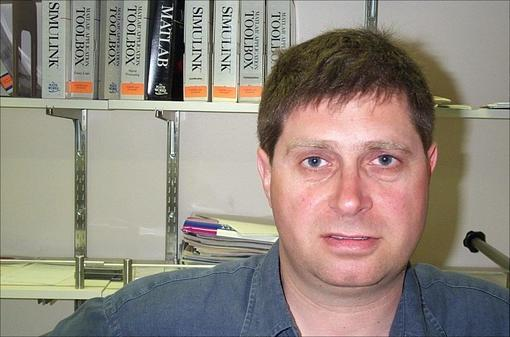

In [47]:
# Find the k most likely matching labels for a given query image for the given feature space.

from utils.query_input_processor import get_query_image

image = get_query_image(IMAGE_INPUT)

print("Input image: ", IMAGE_INPUT)
display(image)

In [48]:
if FEATURE_SPACE == 'color':
    from feature_models.color_moments import ColorMomentsExtractor

    vector = ColorMomentsExtractor(image).get_color_vector()

elif FEATURE_SPACE == 'hog':
    from feature_models.hog import HOGExtractor

    vector = HOGExtractor(image).get_hog_vector()

else:
    # ResNet feature model.
    from feature_models.resnet import ResNetExtractor
    resnet = ResNetExtractor(image)

    if FEATURE_SPACE == 'avgpool':
        vector = resnet.get_avgpool_vector()

    elif FEATURE_SPACE == 'layer3':
        vector = resnet.get_layer3_vector()

    else:
        # fc feature space.
        vector = resnet.get_fc_vector()

In [49]:
# Load feature space vector database into memory.

from utils.database_utils import retrieve
rep_feature_vectors = retrieve(f'rep_label_{FEATURE_SPACE}.pt')

In [50]:
def format_rep_label_db(rep_feature_vectors):
    """
    This function reformat the rep_feature_vectors database into the 
    structure of feature_vectors format {image_id: (label, feature_vector), ...}
    Note: In the fomatted rep_feature_vectors database the image_id is just a sequence.
    This formatting is done to resue distance function
    """
    fmt_rep_feature_vectors = {}
    index = 0

    for k, v in rep_feature_vectors.items():
        for element in v:
            fmt_rep_feature_vectors[index] = (k, element)
            index += 1
    return fmt_rep_feature_vectors

In [51]:
def find_top_k(distances, k):
    result = []
    unique = {}
    for d in distances:
        if d[2] not in unique:
            result.append(d)
            unique[d[2]] = 1
            if len(result) == k:
                break
    return result

In [52]:
fmt_rep_feature_vectors = format_rep_label_db(rep_feature_vectors)

In [53]:
from utils.distance_utils import get_distance_fn, all_distance_ranker
distances = all_distance_ranker(vector, fmt_rep_feature_vectors, get_distance_fn(FEATURE_SPACE))
top_k = find_top_k(distances, K)

print("\nK =", K, " most similar label by ", FEATURE_SPACE, " feature space using distance: ", get_distance_fn(FEATURE_SPACE).__name__)

for i in range(K):
    distance, dummy_image_id, label = top_k[i]

    print(str(i + 1) + ".", "\tLabel: ", label.strip(), "\t\tDistance: ", distance)




K = 5  most similar label by  color  feature space using distance:  cityblock
1. 	Label:  brain 		Distance:  20146.81976731535
2. 	Label:  Faces 		Distance:  20321.89497147042
3. 	Label:  Faces_easy 		Distance:  20422.499875403424
4. 	Label:  lamp 		Distance:  20957.78003999965
5. 	Label:  ewer 		Distance:  21033.20699005756
